In [11]:
import nibabel as nib
import os
import numpy as np
from osl_dynamics.analysis.tinda import tinda, optimise_sequence, plot_cycle
import matplotlib.pyplot as plt

In [2]:
fmri = nib.load('../CIMT_data/forelimb_stim/07d/CCI_002_07d/CCI_none_07d_002.nii')
fmri_data = fmri.get_fdata()
fmri_data.shape

(96, 96, 25, 250)

In [3]:
num_states = 8
tc = np.random.randint(2, size=(fmri_data.shape[3], num_states))
tc.shape

(250, 8)

In [9]:
fo_density, fo_sum, stats = tinda(tc)

In [10]:
best_sequence = optimise_sequence(fo_density)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/osl_dynamics/analysis/tinda.py:641: RuntimeWarning: invalid value encountered in divide
  temp = (fo_density[:, :, 0, :] - fo_density[:, :, 1, :]) / np.mean(
/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/osl_dynamics/analysis/tinda.py:647: RuntimeWarning: invalid value encountered in divide
  np.mean(fo_density[:, :, 0, :] - fo_density[:, :, 1, :], axis=2)


In [12]:
# Find strongest interval asymmetries
mean_direction = np.squeeze(
    np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]), axis=-1) # np.nanmean computes the arithmetic mean along the specified axis, ignoring NaNs
) # np.squeeze remove axes of length one from the input array
mean_direction[np.isnan(mean_direction)] = 0

Plotting results


Text(0.5, 1.0, 'Mean direction')

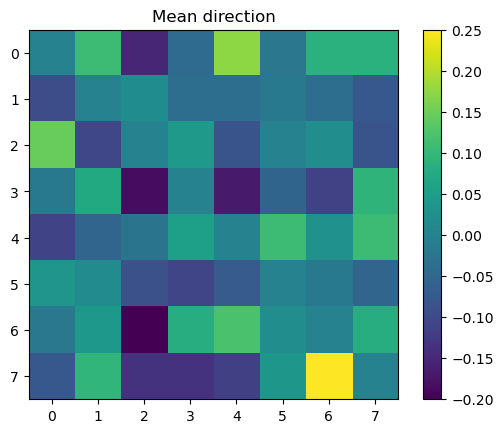

In [13]:
# Find indices of largest 25% values
perc = 0.25
n_largest = int((np.prod(mean_direction.shape) - mean_direction.shape[0]) * perc)
largest_indices = np.abs(mean_direction).argsort(axis=None)[-n_largest:]

strongest_edges = np.zeros(mean_direction.shape)

# Set largest indices to 1
strongest_edges[np.unravel_index(largest_indices, mean_direction.shape)] = 1

# Plot
print("Plotting results")
plt.figure()
plt.imshow(mean_direction)
plt.colorbar()
plt.title("Mean direction")

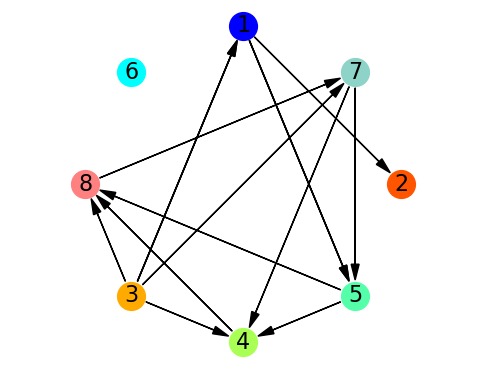

In [14]:
plot_cycle(best_sequence, fo_density, strongest_edges, new_figure=True)